# 导入工具模块

In [1]:
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# 1.载入图片

In [2]:
img_path = 'uk1.jpeg'

In [3]:
img_bgr = cv2.imread(img_path)

In [4]:
img_bgr.shape

(1500, 2250, 3)

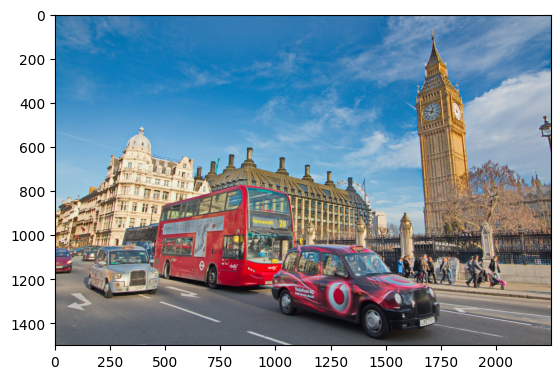

In [5]:
plt.imshow(img_bgr[:,:,::-1])
plt.show()

# 2.创建空白图片

In [6]:
img_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)

# 3.将该图片的labelme格式的json标注文件载入

In [7]:
labelme_json_path = 'uk1.json'

In [8]:
with open(labelme_json_path, 'r', encoding='utf-8') as f:
    labelme = json.load(f)

In [9]:
labelme.keys()

dict_keys(['version', 'flags', 'shapes', 'imagePath', 'imageData', 'imageHeight', 'imageWidth'])

# 4.获取该图片中的所有标注信息

In [11]:
class_info = [
    {'label': 'sky', 'type': 'polygon', 'color': 1},
    {'label': 'road', 'type': 'polygon', 'color': 2},
    {'label': 'building', 'type': 'polygon', 'color': 3},
    {'label': 'tower', 'type': 'polygon', 'color': 4},
    {'label': 'bus', 'type': 'polygon', 'color': 5},
    {'label': 'car', 'type': 'polygon', 'color': 6},
    {'label': 'tree', 'type': 'polygon', 'color': 7},
    {'label': 'fence', 'type': 'polygon', 'color': 8},
    {'label': 'wall', 'type': 'polygon', 'color': 9},
    {'label': 'person', 'type': 'polygon', 'color': 10},
    {'label': 'clock', 'type': 'circle', 'color': 11, 'thickness': -1},
    {'label': 'lane', 'type': 'line', 'color': 12, 'thickness': 5},
    {'label': 'sign', 'type': 'linestrip', 'color': 13, 'thickness': 3}
]

# 5.按顺序将mask绘制到空白图上（只需要两层嵌套）

In [12]:
for one_class in class_info:  # 按顺序遍历每一个类别（保证覆盖顺序）
    for each in labelme['shapes']:  # 遍历所有标注，找到属于当前类别的标注
        if each['label'] == one_class['label']:

            if one_class['type'] == 'polygon':  # polygon 多段线标注
                points = [np.array(each['points'], dtype=np.int32).reshape((-1, 1, 2))]
                img_mask = cv2.fillPoly(img_mask, points, color=one_class['color'])

            elif one_class['type'] == 'line' or one_class['type'] == 'linestrip':  # line 线标注
                points = [np.array(each['points'], dtype=np.int32).reshape((-1, 1, 2))]
                img_mask = cv2.polylines(img_mask, points, isClosed=False, color=one_class['color'],
                                         thickness=one_class['thickness'])

            elif one_class['type'] == 'circle':  # circle 圆形标注
                points = np.array(each['points'], dtype=np.int32)
                center_x, center_y = points[0][0], points[0][1]
                edge_x, edge_y = points[1][0], points[1][1]
                radius = np.linalg.norm(np.array([center_x, center_y] - np.array([edge_x, edge_y]))).astype(
                    'int32')  # 建议这里也用int32，OpenCV画圆需要整数
                img_mask = cv2.circle(img_mask, (center_x, center_y), radius, one_class['color'], one_class['thickness'])
            else:
                print('未知标注类型', one_class['type'])

# 6.保存mask标注图像（必须保存为png格式）

In [13]:
mask_path = img_path.split('.')[0] + '.png'  #保存到与原始图片相同的路径下

In [14]:
cv2.imwrite(mask_path, img_mask)

True

# 7.验证mask是否正确画上png了

In [15]:
print("生成的Mask包含的像素值有：", np.unique(img_mask))

生成的Mask包含的像素值有： [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
